<a href="https://colab.research.google.com/github/moin963khan/Data-/blob/main/Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ----- helper metrics -----
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom == 0
    denom[mask] = 1
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def mape(y_true, y_pred):
    mask = y_true == 0
    y_true_nonzero = y_true.copy()
    y_true_nonzero[mask] = 1e-8
    return np.mean(np.abs((y_true - y_pred) / y_true_nonzero)) * 100

In [ ]:
# ----- synthetic data generator -----
def generate_sku_series(start_date, end_date, base, trend_coeff=0.0, weekly_seas_amp=0.2, noise_level=0.15, promo_prob=0.02, outlier_prob=0.005, seed=None):
    if seed is not None:
        np.random.seed(seed)
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    n = len(dates)
    trend = np.array(1 + trend_coeff * np.arange(n) / n)
    week_day = np.array(dates.weekday)
    weekday_effect = np.array(1 + weekly_seas_amp * (np.sin(2 * np.pi * week_day / 7) + 0.5 * np.cos(2 * np.pi * week_day / 7)))
    noise = np.random.normal(loc=1.0, scale=noise_level, size=n)
    series_vals = np.array(base * trend * weekday_effect * noise, dtype=float)
    promos = np.random.rand(n) < promo_prob
    if promos.sum() > 0:
        bumps = (1 + np.random.uniform(0.5, 1.5, size=promos.sum()))
        series_vals[np.where(promos)] = series_vals[np.where(promos)] * bumps
    outliers = np.random.rand(n) < outlier_prob
    if outliers.sum() > 0:
        bumps = (1 + np.random.uniform(3, 8, size=outliers.sum()))
        series_vals[np.where(outliers)] = series_vals[np.where(outliers)] * bumps
    series_vals = np.round(series_vals).astype(int)
    series_vals[series_vals < 0] = 0
    return pd.Series(series_vals, index=dates)

# ----- generate dataset -----
start_date = pd.Timestamp('2022-01-01')
end_date = pd.Timestamp('2024-12-31')  # ~3 years inclusive
sku_ids = [f"SKU_{i+1:02d}" for i in range(10)]


In [ ]:
daily_df_list = []
np.random.seed(42)
for i, sku in enumerate(sku_ids):
    # create a couple of short-history SKUs to demonstrate filtering
    if sku in ['SKU_09', 'SKU_10']:
        sd = start_date + pd.Timedelta(days=365*2)  # late start => shorter history
        if sku == 'SKU_10':
            sd = end_date - pd.Timedelta(days=50)   # very short history (~50 days)
        series = generate_sku_series(sd, end_date, base=np.random.randint(5, 40),
                                     trend_coeff=np.random.uniform(-0.2, 0.4),
                                     weekly_seas_amp=np.random.uniform(0.1, 0.6),
                                     noise_level=np.random.uniform(0.08, 0.3),
                                     seed=100+i)
    else:
        series = generate_sku_series(start_date, end_date, base=np.random.randint(10, 200),
                                     trend_coeff=np.random.uniform(-0.1, 0.4),
                                     weekly_seas_amp=np.random.uniform(0.1, 0.6),
                                     noise_level=np.random.uniform(0.08, 0.25),
                                     seed=100+i)
    df_tmp = pd.DataFrame({'date': series.index, 'sku': sku, 'sales': series.values})
    daily_df_list.append(df_tmp)

In [ ]:
daily = pd.concat(daily_df_list).reset_index(drop=True)
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['sku', 'date']).reset_index(drop=True)

# introduce a few missing sales days per SKU to show imputation
for sku in sku_ids:
    idx = daily[(daily.sku==sku)].sample(frac=0.01, random_state=hash(sku)%1000).index
    daily.loc[idx, 'sales'] = np.nan



In [ ]:
daily

,date,sku,sales
0,2022-01-01,SKU_01,56.0
1,2022-01-02,SKU_01,109.0
2,2022-01-03,SKU_01,153.0
3,2022-01-04,SKU_01,128.0
4,2022-01-05,SKU_01,158.0
...,...,...,...
9180,2024-12-27,SKU_10,5.0
9181,2024-12-28,SKU_10,4.0
9182,2024-12-29,SKU_10,6.0
9183,2024-12-30,SKU_10,11.0


In [ ]:
# ----- resample to weekly (W-MON) -----
daily.set_index('date', inplace=True)
weekly = daily.groupby('sku').sales.resample('W-MON').sum().reset_index().rename(columns={'sales':'weekly_sales'})

# pivot to series dict per SKU
sku_series = {}
for sku, grp in weekly.groupby('sku'):
    s = grp.set_index('date').weekly_sales.asfreq('W-MON')
    sku_series[sku] = s

In [ ]:
weekly

,sku,date,weekly_sales
0,SKU_01,2022-01-03,318.0
1,SKU_01,2022-01-10,675.0
2,SKU_01,2022-01-17,785.0
3,SKU_01,2022-01-24,813.0
4,SKU_01,2022-01-31,868.0
...,...,...,...
1322,SKU_10,2024-12-09,63.0
1323,SKU_10,2024-12-16,57.0
1324,SKU_10,2024-12-23,62.0
1325,SKU_10,2024-12-30,61.0


In [ ]:
weekly = daily.groupby('sku').sales.resample('W-MON').sum().reset_index().rename(columns={'sales':'weekly_sales'})


In [ ]:
weekly

,sku,date,weekly_sales
0,SKU_01,2022-01-03,318.0
1,SKU_01,2022-01-10,675.0
2,SKU_01,2022-01-17,785.0
3,SKU_01,2022-01-24,813.0
4,SKU_01,2022-01-31,868.0
...,...,...,...
1322,SKU_10,2024-12-09,63.0
1323,SKU_10,2024-12-16,57.0
1324,SKU_10,2024-12-23,62.0
1325,SKU_10,2024-12-30,61.0


In [ ]:
# ----- filter SKUs with less than 3 months (~13 weeks) history -----
min_weeks = 13
eligible_skus = [sku for sku, s in sku_series.items() if s.dropna().shape[0] >= min_weeks]
sku_series = {sku: sku_series[sku] for sku in eligible_skus}


SKU: SKU_01
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 12
ADF stat=-9.7380, p=0.0000


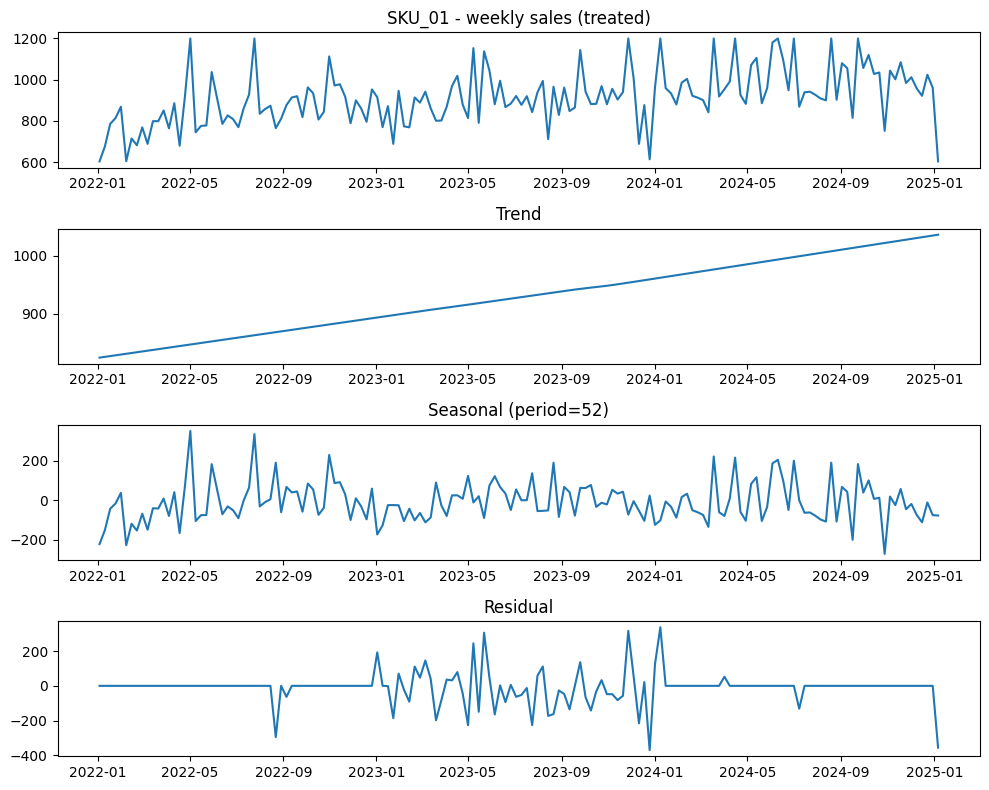

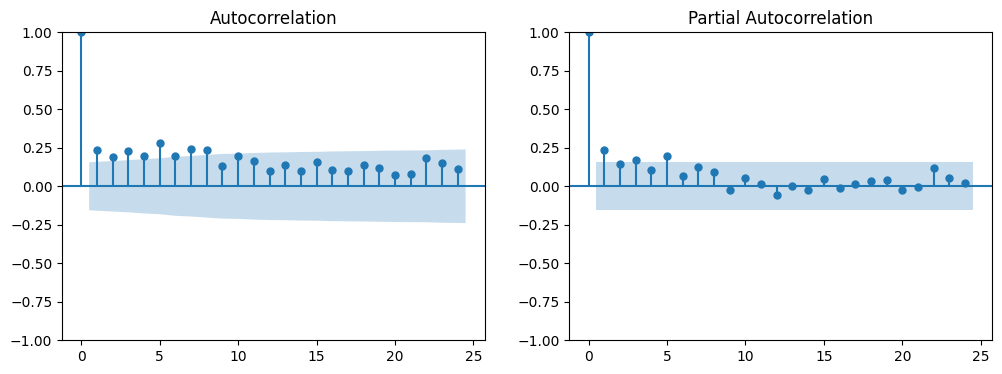

Train weeks: 146, test weeks: 12

SKU: SKU_02
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 9
ADF stat=-1.7836, p=0.3886


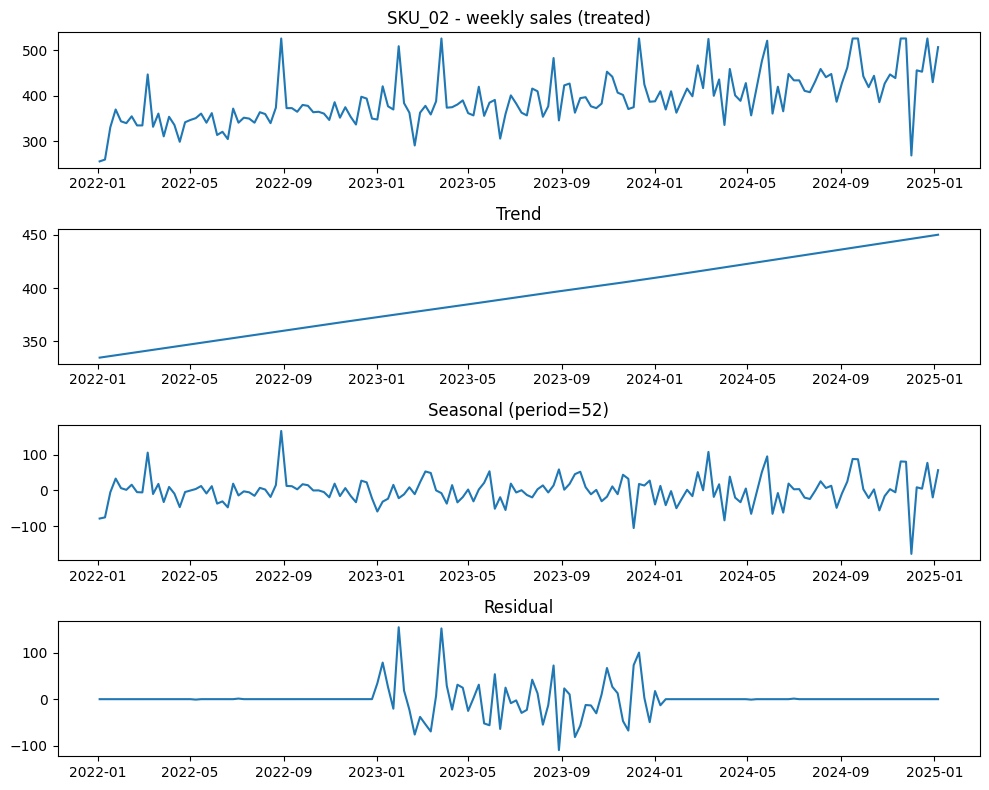

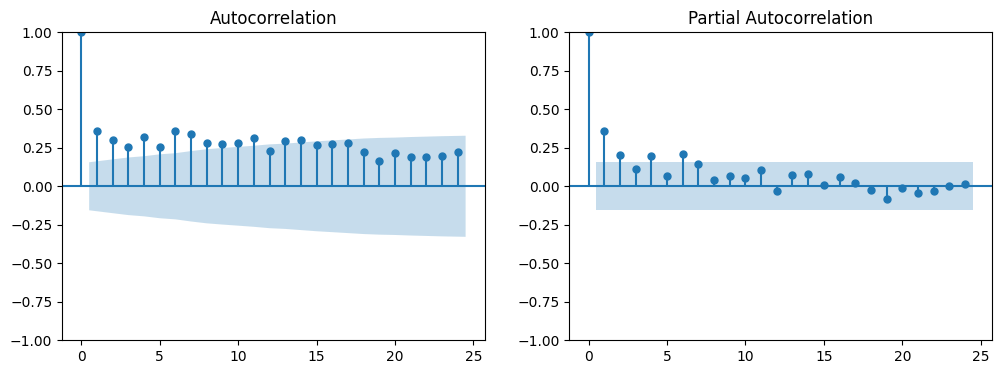

Train weeks: 146, test weeks: 12

SKU: SKU_03
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 12
ADF stat=-9.7324, p=0.0000


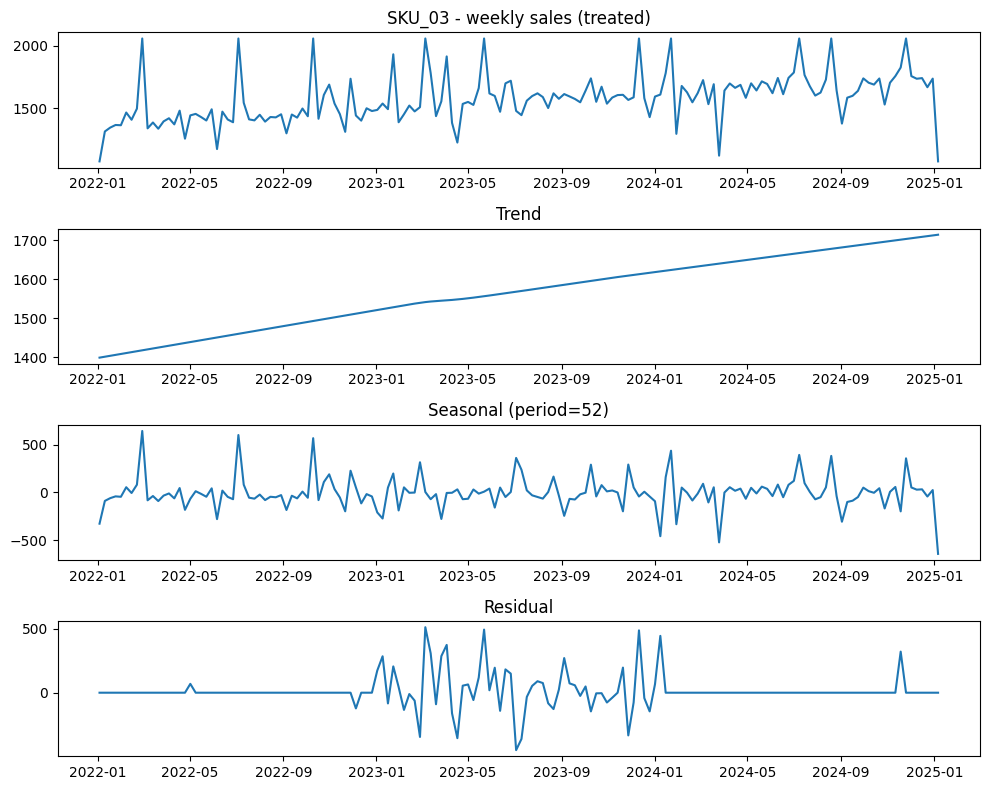

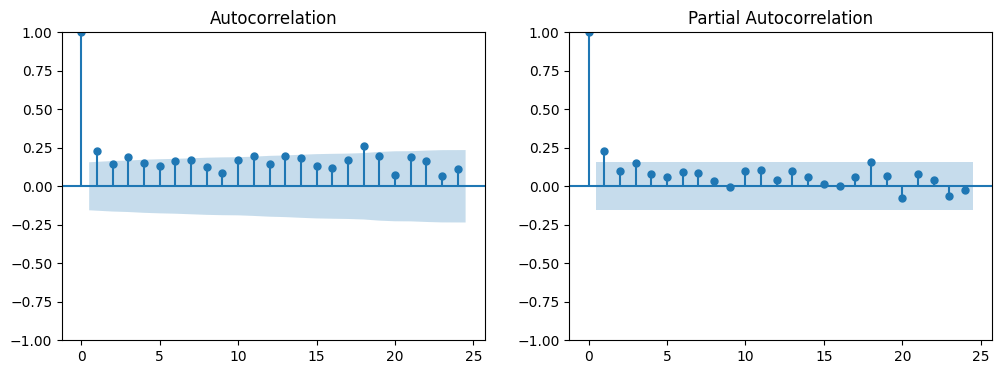

Train weeks: 146, test weeks: 12

SKU: SKU_04
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 5
ADF stat=-1.7168, p=0.4225


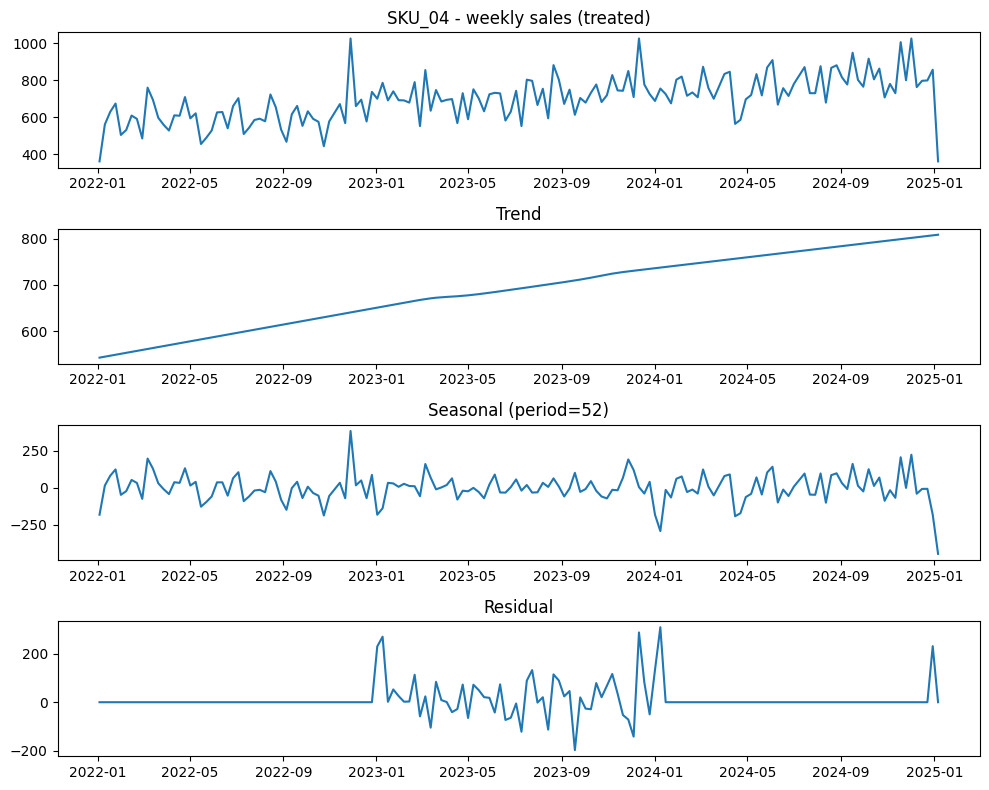

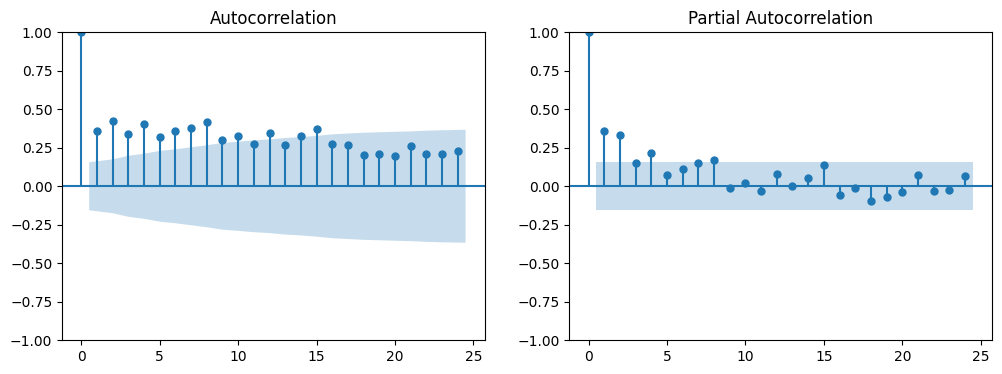

Train weeks: 146, test weeks: 12

SKU: SKU_05
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 14
ADF stat=-12.6230, p=0.0000


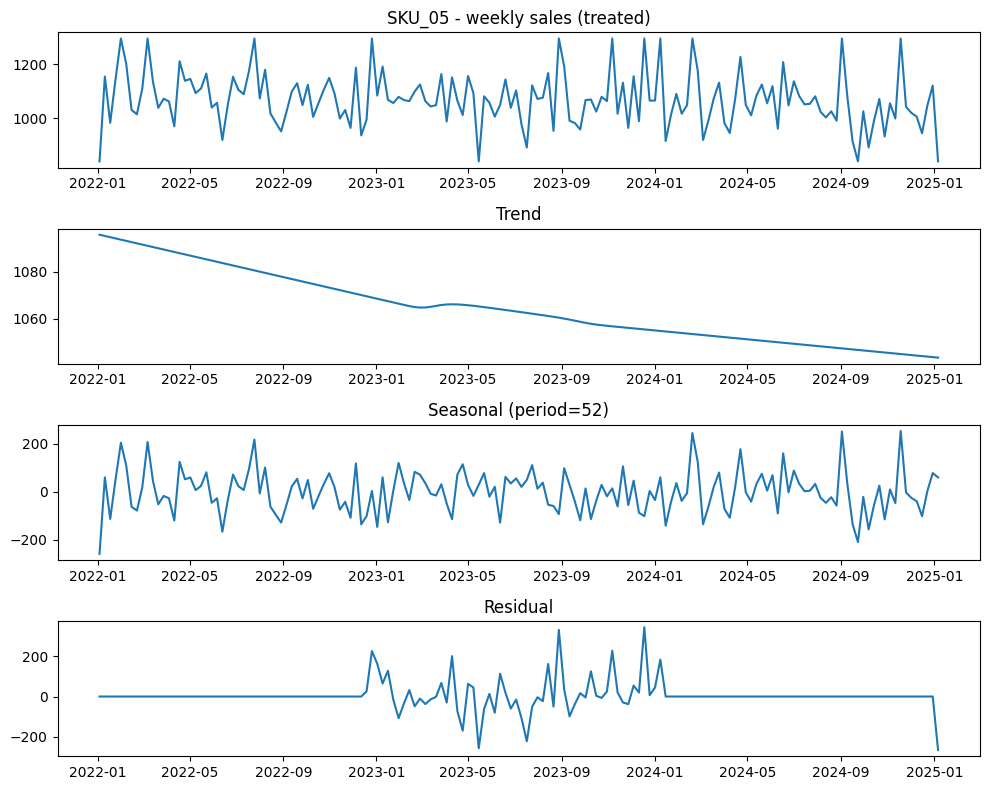

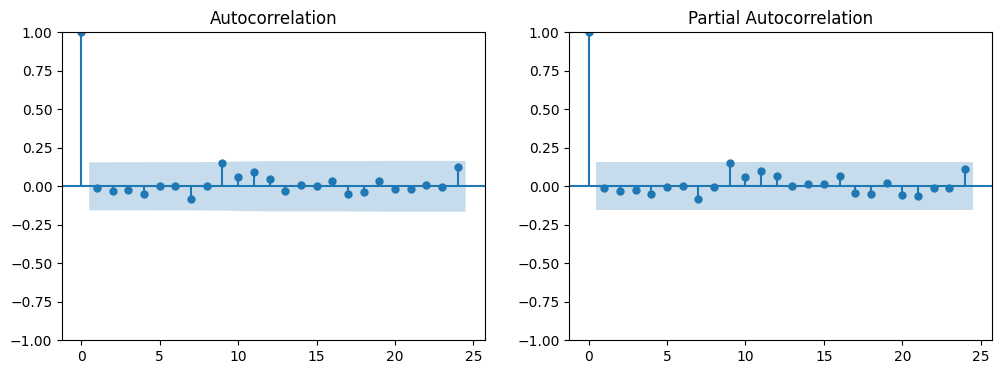

Train weeks: 146, test weeks: 12

SKU: SKU_06
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 8
ADF stat=-1.4650, p=0.5508


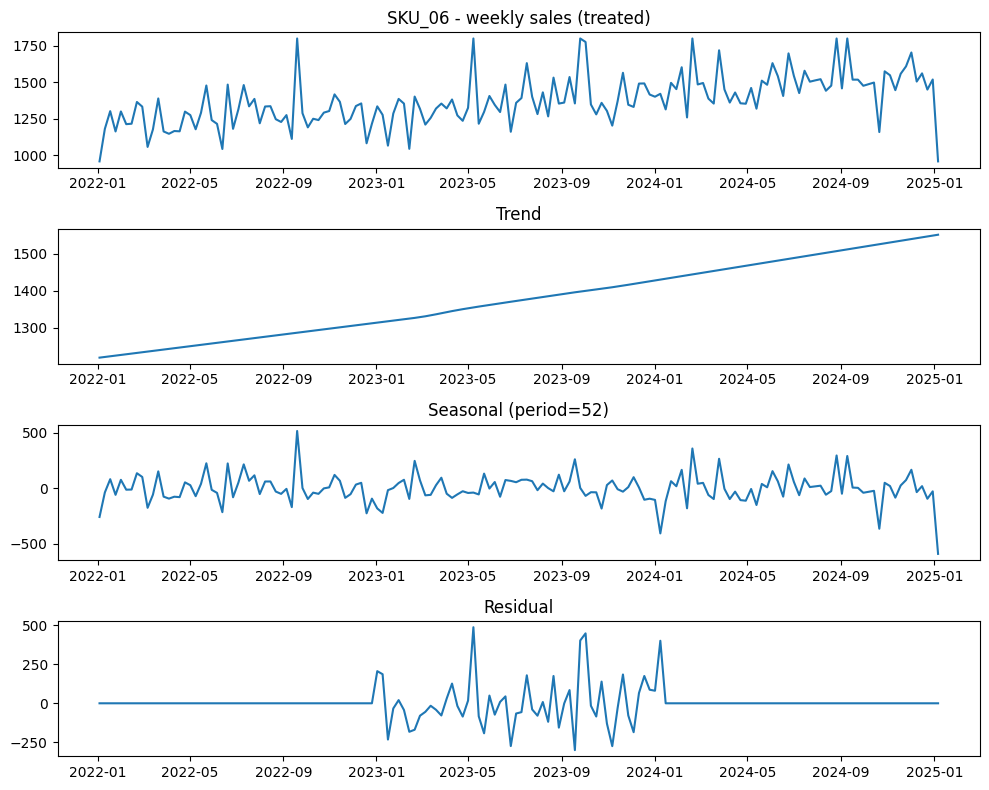

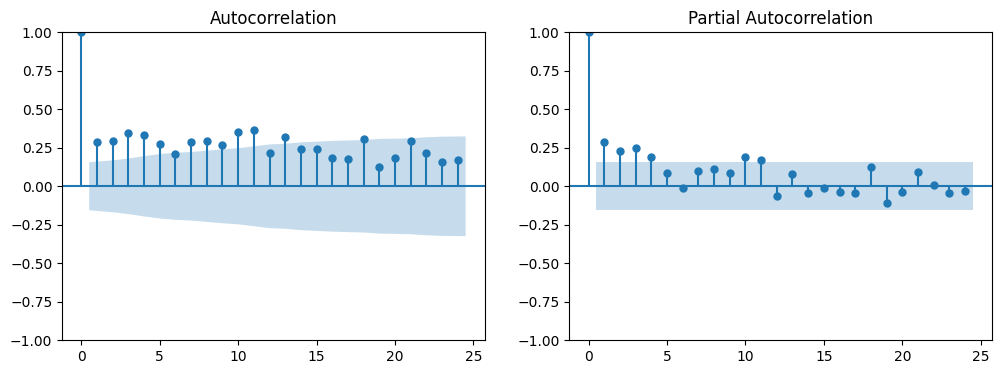

Train weeks: 146, test weeks: 12

SKU: SKU_07
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 18
ADF stat=-4.4655, p=0.0002


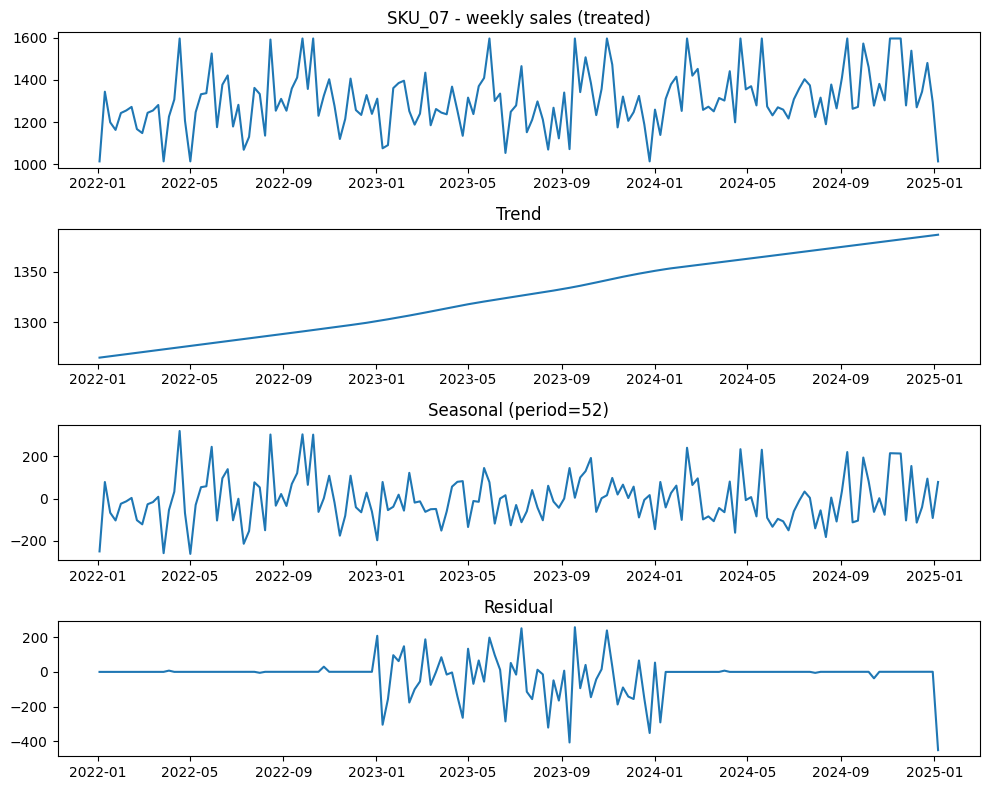

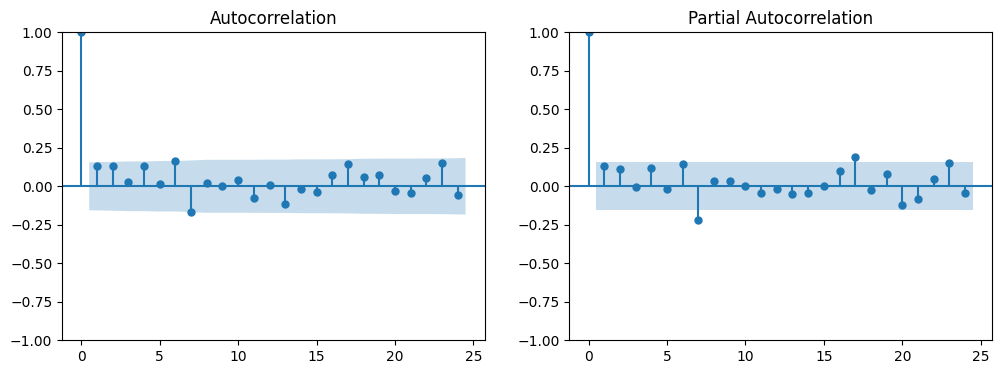

Train weeks: 146, test weeks: 12

SKU: SKU_08
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 13
ADF stat=-12.3149, p=0.0000


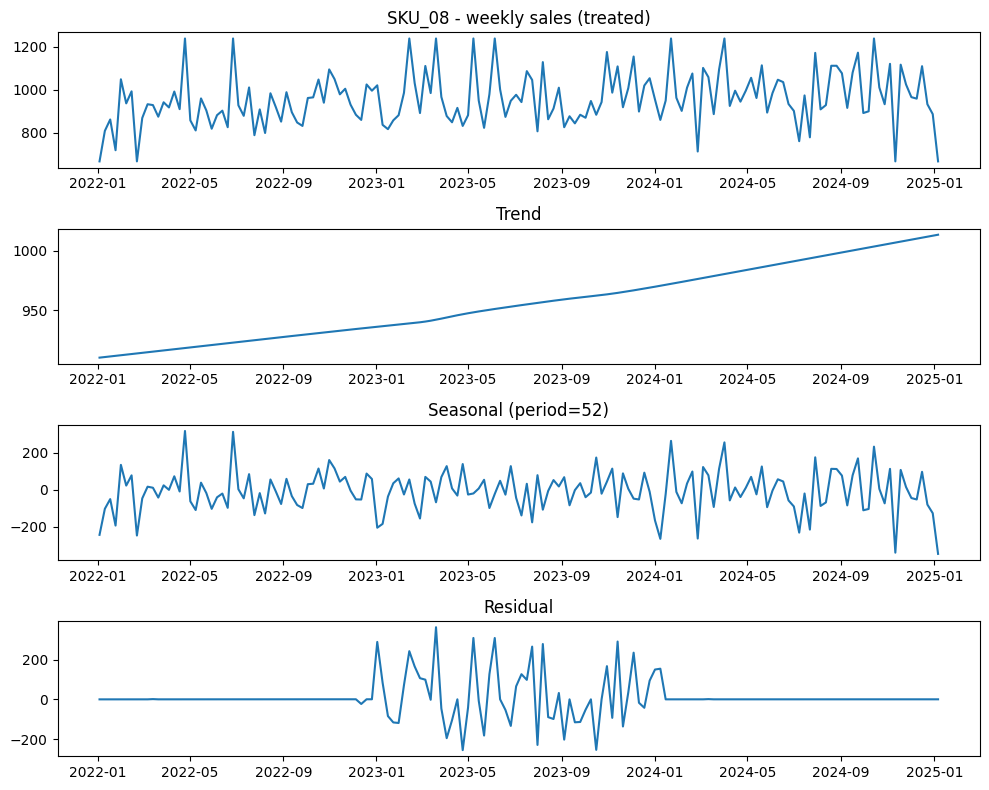

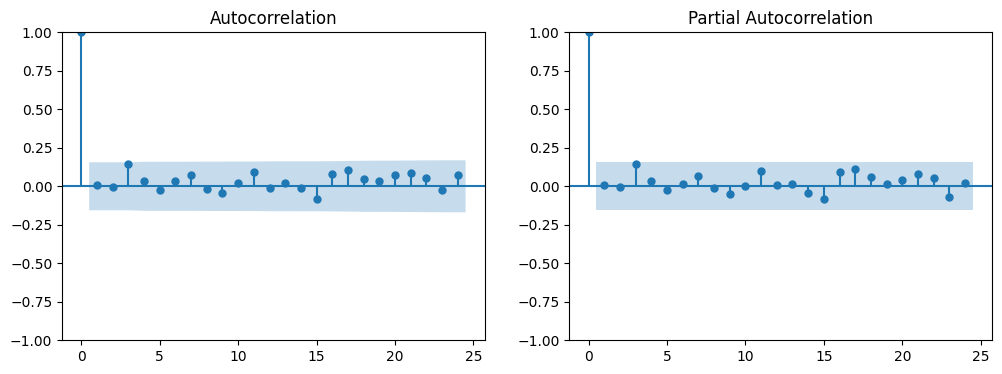

Train weeks: 146, test weeks: 12

SKU: SKU_09
Missing weeks before: 0, after imputation: 0
Outlier weeks detected: 9
ADF stat=-7.4683, p=0.0000


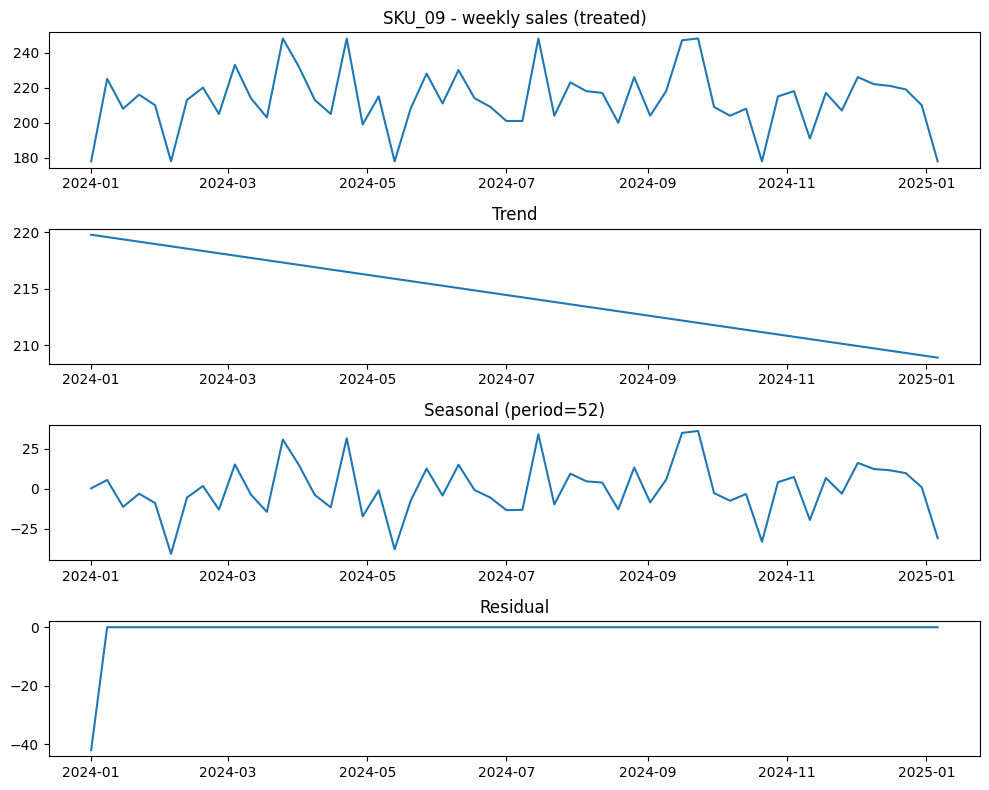

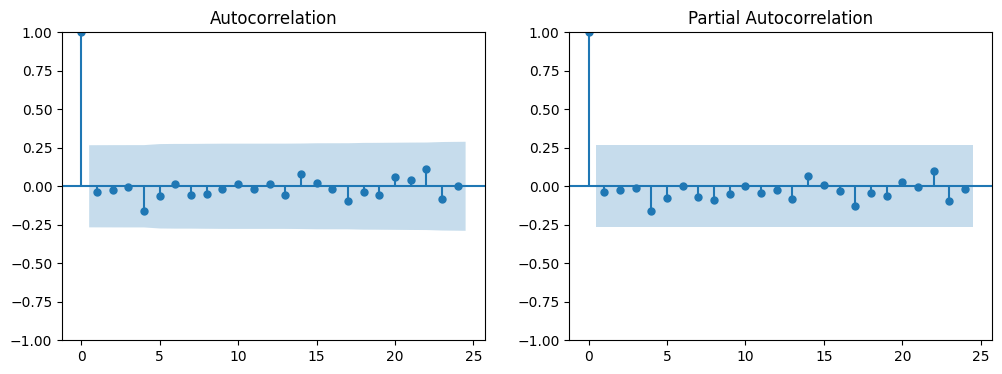

Train weeks: 42, test weeks: 12


In [ ]:
# ----- per-SKU processing and modeling -----
results = {}
plt.rcParams['figure.figsize'] = (10,4)
seasonal_period = 52  # weekly series -> yearly seasonality (52 weeks)
test_weeks = 12

for sku, s in sku_series.items():
    print("\n" + "="*60)
    print("SKU:", sku)
    print("="*60)
    data = s.copy()

    # 1) Imputation (ffill -> bfill -> mean)
    n_missing_before = data.isna().sum()
    data_imputed = data.fillna(method='ffill').fillna(method='bfill')
    data_imputed = data_imputed.fillna(round(data_imputed.mean()))
    n_missing_after = data_imputed.isna().sum()
    print(f"Missing weeks before: {n_missing_before}, after imputation: {n_missing_after}")

    # 2) Outliers via IQR -> clip
    q1 = data_imputed.quantile(0.25)
    q3 = data_imputed.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = (data_imputed < lower) | (data_imputed > upper)
    n_outliers = outliers.sum()
    print(f"Outlier weeks detected: {int(n_outliers)}")
    data_treated = data_imputed.copy()
    data_treated[data_treated < lower] = round(lower)
    data_treated[data_treated > upper] = round(upper)

    # 3) Stationarity (ADF)
    adf_res = adfuller(data_treated)
    print(f"ADF stat={adf_res[0]:.4f}, p={adf_res[1]:.4f}")

    # 4) Decompose (STL) - period=52
    try:
        stl = STL(data_treated, period=seasonal_period, robust=True)
        res_stl = stl.fit()
        fig = plt.figure(figsize=(10,8))
        ax1 = fig.add_subplot(411); ax1.plot(data_treated); ax1.set_title(f"{sku} - weekly sales (treated)")
        ax2 = fig.add_subplot(412); ax2.plot(res_stl.trend); ax2.set_title("Trend")
        ax3 = fig.add_subplot(413); ax3.plot(res_stl.seasonal); ax3.set_title(f"Seasonal (period={seasonal_period})")
        ax4 = fig.add_subplot(414); ax4.plot(res_stl.resid); ax4.set_title("Residual")
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("STL failed:", e)

    # 5) ACF / PACF
    fig, ax = plt.subplots(1,2,figsize=(12,4))
    plot_acf(data_treated, lags=24, ax=ax[0])
    plot_pacf(data_treated, lags=24, ax=ax[1], method='ywm')
    plt.show()

    # 6) Train-test split (last 12 weeks test)
    train = data_treated.iloc[:-test_weeks]
    test = data_treated.iloc[-test_weeks:]
    print(f"Train weeks: {len(train)}, test weeks: {len(test)}")


In [ ]:
train = data_treated.iloc[:-test_weeks]
test = data_treated.iloc[-test_weeks:]